<a href="https://colab.research.google.com/github/mochamadx5/MachineLearning_11_MochamadReza/blob/main/JS04/JS04_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# import package
import numpy as np
import pandas as pd

data = pd.read_csv('dataset.csv')

In [3]:
# melihat beberapa data awal
data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\r\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\r\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\r\nCobbborough,...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\r\nPort Jason, OH 22070-...",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\r\nPort Jacobville, PR...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
#mengecek ukuran data
data.shape

(500, 8)

In [5]:
# informasi tentang data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [6]:
# deskripsi data
data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


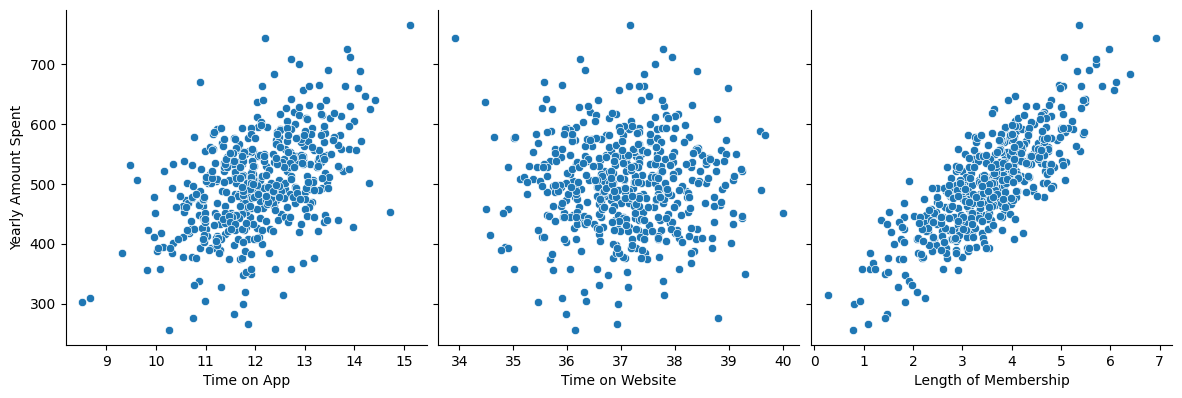

In [9]:
# Langkah 5 : Visualisasi Data
# import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
# visualisasi data dengan pairplot
sns.pairplot(data, x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
             y_vars= 'Yearly Amount Spent', size=4, aspect=1, kind='scatter')
plt.show()

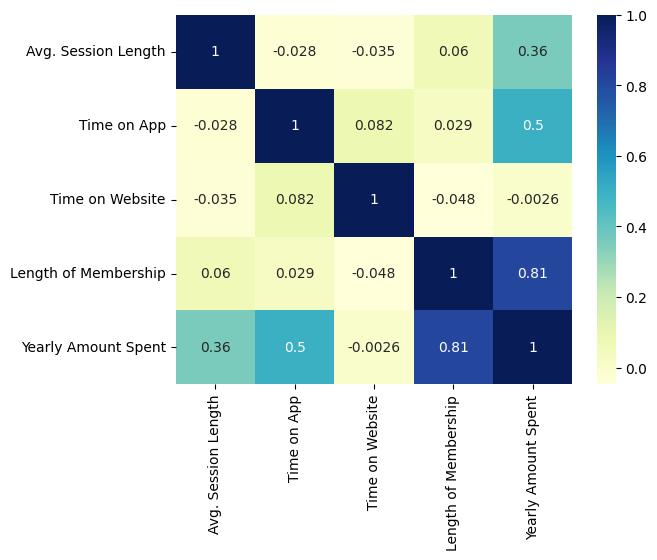

In [13]:
# visualisasi korelasi dengan heatmap
sns.heatmap(data.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.show()

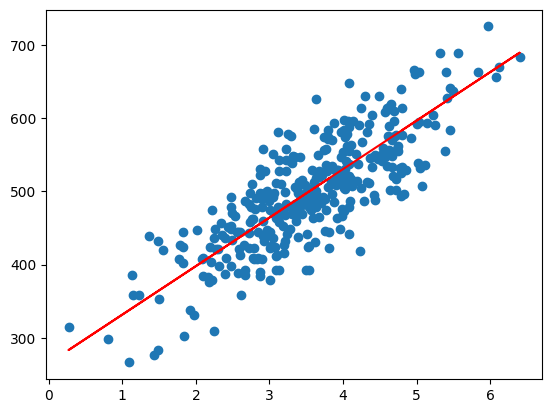

In [22]:
# Membuat variabel bebas X dan Y, contoh pengambilan dari analisis korelasi sebelumnya
x = data ['Length of Membership']
y = data ['Yearly Amount Spent']

# Pembagian data latih dan data uji dengan proporsi 7:3
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, test_size=0.3, random_state=101)

# training model
import statsmodels.api as sm
x_train2 = sm.add_constant(x_train)
lr = sm.OLS(y_train, x_train2).fit()

# Visualisasi garis regresi
plt.scatter(x_train, y_train)
plt.plot(x_train, 265.2483 + 66.3015*x_train, 'r')
plt.show()

/tmp/ipykernel_812/1111433550.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res, bins=15)


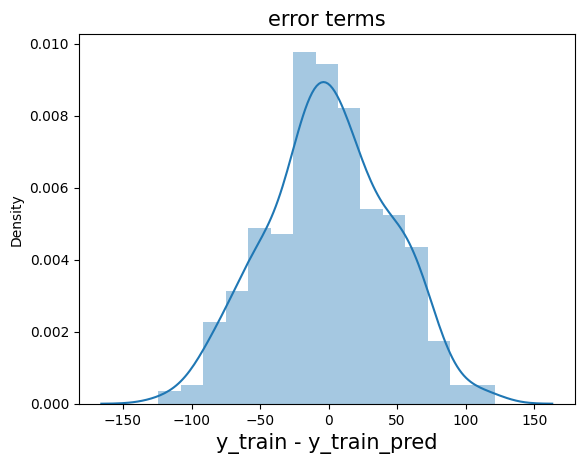

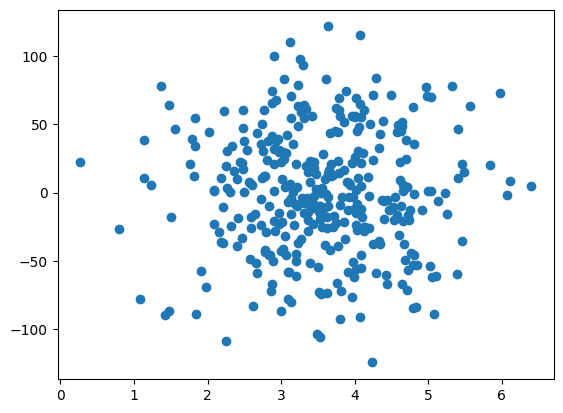

In [25]:
# Menghitung nilai prediksi dan residual (res)
y_train_pred = lr.predict(x_train2)
res = y_train - y_train_pred

# histogram residual
fig = plt.figure()
sns.distplot(res, bins=15)
plt.title('error terms', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=15)
plt.show()

# scatter plot residual
plt.scatter(x_train, res)
plt.show()

In [30]:
# Prediksi pada Data Uji dan Evaluasi Model
x_test_sm = sm.add_constant(x_test)
y_test_pred = lr.predict(x_test_sm)

# hitung nilai r-squared
from sklearn.metrics import r2_score
r2_score(y_test, y_test_pred)

0.6484902730789126

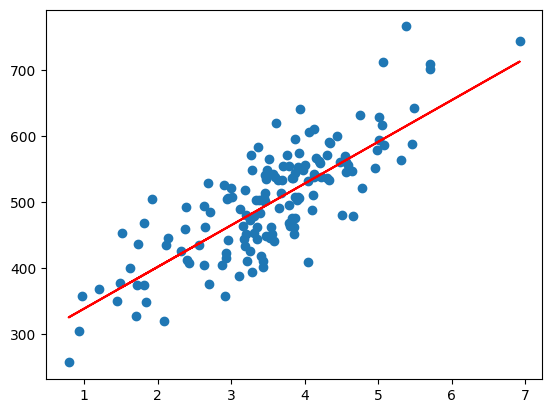

In [32]:
# Visualisasi data uji dan hasil prediksi
plt.scatter(x_test, y_test)
plt.plot(x_test, y_test_pred, 'r')
plt.show()